# Carnet 01 : Analyse Exploratoire (EDA) et Modèles de Référence (Baseline)
**Auteur :** Kaan BILGIC
**Projet :** Détection d'anomalies IoT par Machine Learning

**Objectif de ce carnet :** Ce script charge le dataset Edge-IIoTset, effectue le nettoyage des données textuelles, normalise les variables, et entraîne deux modèles de détection d'anomalies non supervisés (Isolation Forest et Autoencoder) pour établir une baseline de performance.
---

In [1]:
## 1. Importation des bibliothèques et configuration visuelle.

# Cellule 1 : Importation des bibliothèques et configuration visuelle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration visuelle académique pour les futurs rapports (format article)
plt.style.use('seaborn-v0_8-whitegrid') # Style propre, lisible et sobre
sns.set_context("paper", font_scale=1.2) # Taille de police adaptée pour une exportation PDF
plt.rcParams['figure.figsize'] = (10, 6) # Taille par défaut des figures
plt.rcParams['axes.titlesize'] = 14      # Mise en évidence des titres

print("Cellule 1 exécutée : Bibliothèques importées.")

Cellule 1 exécutée : Bibliothèques importées.


In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. On vérifie la position exacte de Jupyter
current_dir = os.getcwd()
print(f"Jupyter s'exécute actuellement depuis : {current_dir}")

# 2. Le bon chemin relatif (on remonte d'un cran avec ../, puis on rentre dans data)
file_path = "../data/sample_DNN-EdgeIIoT.csv"

# 3. Test de sécurité avant de charger
chemin_absolu_calcule = os.path.abspath(file_path)
print(f"Python cherche le fichier exactement ici : {chemin_absolu_calcule}")

if not os.path.exists(file_path):
    print("ERREUR : Le fichier est introuvable à cet endroit.")
else:
    print("SUCCÈS : Fichier trouvé ! Début du chargement...")
    try:
        df_full = pd.read_csv(file_path, low_memory=False)
        print(f"Dataset chargé. Taille brute : {df_full.shape}")

        target_col = 'Attack_type' if 'Attack_type' in df_full.columns else df_full.columns[-1]

        n_samples = 500000
        if len(df_full) > n_samples:
            df_sampled, _ = train_test_split(
                df_full, 
                train_size=n_samples, 
                stratify=df_full[target_col], 
                random_state=42
            )
            print(f"Échantillonnage réussi. Nouvelle taille optimisée : {df_sampled.shape}")
        else:
            df_sampled = df_full.copy()
            print("Le dataset fait déjà moins de 500 000 lignes.")

        del df_full

        print(f"\nRépartition des classes sur la colonne '{target_col}' :")
        distribution = df_sampled[target_col].value_counts(normalize=True) * 100
        for index, value in distribution.items():
            print(f"- {index} : {value:.2f}%")
            
        normal_count = len(df_sampled[df_sampled[target_col] == 'Normal'])
        print(f"\n-> Nombre exact de trames 'Normal' disponibles : {normal_count}")

    except Exception as e:
        print(f"Une erreur est survenue lors de la lecture : {e}")

Jupyter s'exécute actuellement depuis : C:\Users\Chr\Desktop\IoT-Anomaly-Detection-ML\notebook
Python cherche le fichier exactement ici : C:\Users\Chr\Desktop\IoT-Anomaly-Detection-ML\data\sample_DNN-EdgeIIoT.csv
SUCCÈS : Fichier trouvé ! Début du chargement...
Dataset chargé. Taille brute : (150000, 63)
Le dataset fait déjà moins de 500 000 lignes.

Répartition des classes sur la colonne 'Attack_type' :
- Normal : 72.85%
- DDoS_UDP : 5.48%
- DDoS_ICMP : 5.27%
- DDoS_HTTP : 2.30%
- Vulnerability_scanner : 2.25%
- Password : 2.25%
- DDoS_TCP : 2.24%
- SQL_injection : 2.23%
- Uploading : 1.67%
- Backdoor : 1.10%
- Port_Scanning : 1.06%
- XSS : 0.70%
- Ransomware : 0.50%
- MITM : 0.05%
- Fingerprinting : 0.04%

-> Nombre exact de trames 'Normal' disponibles : 109274


1. Génération du graphique de distribution des classes...


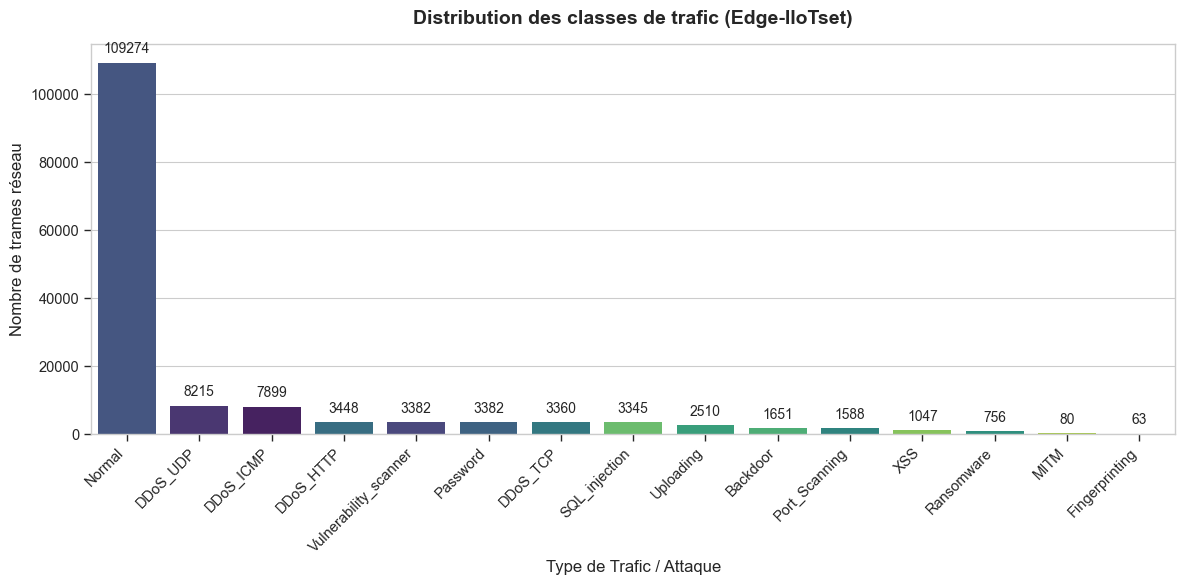


2. Audit des données (Data Profiling) pour le futur nettoyage :
Types de colonnes présentes sur les 63 features :
float64    42
str        20
int64       1
Name: count, dtype: int64

Nombre total de valeurs manquantes (NaN) dans tout le dataset : 0

Colonnes de type 'texte' (à encoder ou supprimer pour le ML) : ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname', 'mqtt.topic', 'Attack_type']


In [3]:
## 3. Visualisation de la distribution et Audit des types

# Cellule 3 : Visualisation académique et Audit des types de données (Tâche 1.2 & 1.3)
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Génération du graphique de distribution des classes...")

# Configuration du graphique académique
plt.figure(figsize=(12, 6))
# On utilise la colonne cible dynamique définie dans la cellule précédente
ax = sns.countplot(data=df_sampled, x=target_col, hue=target_col, legend=False,
                   order=df_sampled[target_col].value_counts().index, palette='viridis')

plt.title("Distribution des classes de trafic (Edge-IIoTset)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Type de Trafic / Attaque", fontsize=12)
plt.ylabel("Nombre de trames réseau", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotation des étiquettes pour la lisibilité

# Ajout des valeurs exactes au-dessus des barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n2. Audit des données (Data Profiling) pour le futur nettoyage :")
# Comptage des types de variables (Combien de colonnes numériques vs texte/catégorique)
types_count = df_sampled.dtypes.value_counts()
print(f"Types de colonnes présentes sur les 63 features :\n{types_count}")

# Vérification des valeurs manquantes (NaN)
nan_total = df_sampled.isna().sum().sum()
print(f"\nNombre total de valeurs manquantes (NaN) dans tout le dataset : {nan_total}")

# Aperçu des colonnes de type 'object' (généralement du texte comme les adresses IP)
cols_object = df_sampled.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"\nColonnes de type 'texte' (à encoder ou supprimer pour le ML) : {cols_object}")

In [4]:
## 4. Nettoyage des caractéristiques et Normalisation (StandardScaler)

# Cellule 4 : Nettoyage des données et Normalisation (Tâche 1.3)
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("Début de la Tâche 1.3 : Nettoyage et Prétraitement...")

# 1. Liste exacte des colonnes textuelles à exclure (identifiants, IP, requêtes brutes)
cols_to_drop = ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 
                'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query', 
                'http.request.method', 'http.referer', 'http.request.full_uri', 
                'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport', 
                'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname', 
                'mqtt.topic']

# 2. Séparation des caractéristiques (X) et de la cible (y)
y = df_sampled['Attack_type'].copy()

# On supprime la cible et les colonnes textuelles pour ne garder que les maths
X = df_sampled.drop(columns=cols_to_drop + ['Attack_type'], errors='ignore')

print(f"-> Colonnes textuelles supprimées. Nouvelles dimensions de la matrice X : {X.shape}")

# 3. Sécurité : Forcer le format numérique strict
# Si un nombre était caché en format texte, on le force en 'float64'. 
# S'il y a des erreurs (ex: un tiret '-'), on remplace par 0 (coerce + fillna).
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 4. Normalisation StandardScaler 
print("-> Application du StandardScaler en cours...")
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# On remet le résultat (qui est un tableau Numpy) sous forme de DataFrame Pandas pour y voir clair
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("\nOpération réussie ! Voici un aperçu des 5 premières lignes du dataset normalisé :")
display(X_scaled.head())

Début de la Tâche 1.3 : Nettoyage et Prétraitement...
-> Colonnes textuelles supprimées. Nouvelles dimensions de la matrice X : (150000, 43)
-> Application du StandardScaler en cours...

Opération réussie ! Voici un aperçu des 5 premières lignes du dataset normalisé :


,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.content_length,http.response,http.tls_port,tcp.ack,...,mqtt.len,mqtt.msg_decoded_as,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label
0,-0.051131,-0.054054,6.272241,6.809894,-0.005774,0.0,-0.086319,-0.121270,0.0,-0.136797,...,-0.261409,0.0,-0.278734,-0.199183,-0.198567,-0.199183,-0.007899,-0.007795,-0.00679,1.638033
1,-0.051131,-0.054054,-0.203908,2.779887,-0.005774,0.0,-0.086319,-0.121270,0.0,-0.136797,...,-0.261409,0.0,-0.278734,-0.199183,-0.198567,-0.199183,-0.007899,-0.007795,-0.00679,1.638033
2,-0.051131,-0.054054,1.457417,1.990561,-0.005774,0.0,-0.086319,-0.121270,0.0,-0.136797,...,-0.261409,0.0,-0.278734,-0.199183,-0.198567,-0.199183,-0.007899,-0.007795,-0.00679,1.638033
3,-0.051131,-0.054054,-0.203908,-0.215215,-0.005774,0.0,5.041314,8.246044,0.0,-0.136701,...,-0.261409,0.0,-0.278734,-0.199183,-0.198567,-0.199183,-0.007899,-0.007795,-0.00679,1.638033
4,-0.051131,-0.054054,-0.203908,-0.215215,-0.005774,0.0,-0.086319,-0.121270,0.0,1.058262,...,-0.261409,0.0,-0.278734,-0.199183,-0.198567,-0.199183,-0.007899,-0.007795,-0.00679,-0.610488


In [5]:
## 5. Sauvegarde du dataset pré-traité

# Cellule 5 : Sauvegarde du dataset pré-traité (Fin de la Phase 1)
import pandas as pd
import os

print("Préparation de la sauvegarde...")

# 1. On fusionne tes variables normalisées (X) et ta colonne cible (y)
df_processed = X_scaled.copy()
# On utilise .values pour éviter les problèmes d'index lors de la fusion
df_processed['Attack_type'] = y.values 

# 2. Chemin absolu vers ton dossier 'processed' (Validé dans ton architecture)
output_dir = "../data/processed"
output_file = os.path.join(output_dir, "EdgeIIoT_processed_clean.csv")

try:
    # 3. Création du dossier s'il n'existe pas, puis sauvegarde
    os.makedirs(output_dir, exist_ok=True)
    df_processed.to_csv(output_file, index=False)
    
    print(f"Succès ! Le dataset nettoyé a été sauvegardé ici :\n-> {output_file}")
except Exception as e:
    print(f"Erreur lors de la sauvegarde : {e}")

Préparation de la sauvegarde...
Succès ! Le dataset nettoyé a été sauvegardé ici :
-> ../data/processed\EdgeIIoT_processed_clean.csv


Début de la Phase 2 : Modélisation de la Baseline...
-> Taille du set d'entraînement (100% Normal) : (87419, 43)
-> Taille du set de test (Normal + Attaques) : (62581, 43)

Entraînement de l'Isolation Forest en cours
Évaluation sur le trafic inconnu

--- RÉSULTATS DE LA BASELINE ---
Exactitude Globale (Accuracy) : 48.44%
F1-Score (Détection d'anomalies) : 0.4447


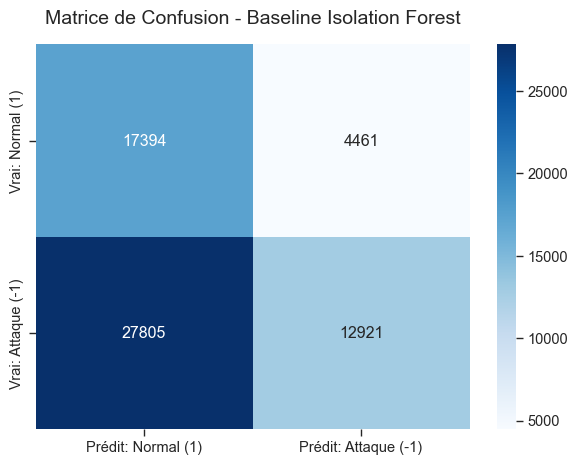

In [6]:
## 6. Modèle Baseline 1 : Isolation Forest

# Cellule 6 : Entraînement de l'Isolation Forest (Tâche 2.1 & 2.3)
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("Début de la Phase 2 : Modélisation de la Baseline...")

# 1. Séparation Train (Normal uniquement) / Test (Mélange)
# On filtre le dataset nettoyé qui est déjà en mémoire
df_normal = df_processed[df_processed['Attack_type'] == 'Normal'].copy()
df_attack = df_processed[df_processed['Attack_type'] != 'Normal'].copy()

# On prend 80% du trafic normal pour l'apprentissage (Train)
train_size = int(0.8 * len(df_normal))
df_train_normal = df_normal.iloc[:train_size]

# Le reste du trafic normal (20%) + TOUTES les attaques vont dans l'évaluation (Test)
df_test = pd.concat([df_normal.iloc[train_size:], df_attack])

# 2. Préparation des matrices mathématiques (X) et des labels (y)
X_train = df_train_normal.drop(columns=['Attack_type'])

X_test = df_test.drop(columns=['Attack_type'])
y_test_labels = df_test['Attack_type']

# Convention Scikit-Learn pour l'Isolation Forest : 1 = Normal (Inlier), -1 = Anomalie (Outlier)
y_test_binary = y_test_labels.apply(lambda x: 1 if x == 'Normal' else -1)

print(f"-> Taille du set d'entraînement (100% Normal) : {X_train.shape}")
print(f"-> Taille du set de test (Normal + Attaques) : {X_test.shape}")

# 3. Initialisation et Entraînement du modèle
print("\nEntraînement de l'Isolation Forest en cours")
# n_estimators=100 (100 arbres), contamination='auto' (laisse le modèle juger le seuil d'anomalie)
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

# 4. Prédictions sur le set de test
print("Évaluation sur le trafic inconnu")
y_pred = iso_forest.predict(X_test)

# 5. Extraction des Métriques
print("\n--- RÉSULTATS DE LA BASELINE ---")
# pos_label=-1 car on veut mesurer la capacité à détecter les attaques
f1 = f1_score(y_test_binary, y_pred, pos_label=-1) 
acc = accuracy_score(y_test_binary, y_pred)

print(f"Exactitude Globale (Accuracy) : {acc*100:.2f}%")
print(f"F1-Score (Détection d'anomalies) : {f1:.4f}")

# 6. Génération de la Matrice de Confusion
cm = confusion_matrix(y_test_binary, y_pred, labels=[1, -1])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit: Normal (1)', 'Prédit: Attaque (-1)'], 
            yticklabels=['Vrai: Normal (1)', 'Vrai: Attaque (-1)'])
plt.title("Matrice de Confusion - Baseline Isolation Forest", fontsize=14, pad=15)
plt.show()

Début de la Tâche 2.2 : Construction de l'Autoencoder avec TensorFlow


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 43)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,179 (16.32 KB)

 Trainable params: 4,179 (16.32 KB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement en cours 
Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2356 - val_loss: 0.1880
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1762 - val_loss: 0.1649
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1634 - val_loss: 0.1580
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1519 - val_loss: 0.1448
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1449 - val_loss: 0.1438
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1444 - val_loss: 0.1434
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1440 - val_loss: 0.1430
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1437 - val_loss: 0.1427
Epoch 9/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1434 - val_loss: 0.1423
Epoch 10/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1429 - val_loss: 0.1420
Epoch 11/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1425 - val_loss: 0.1415
Epoch 12/20
154/154 ━━━

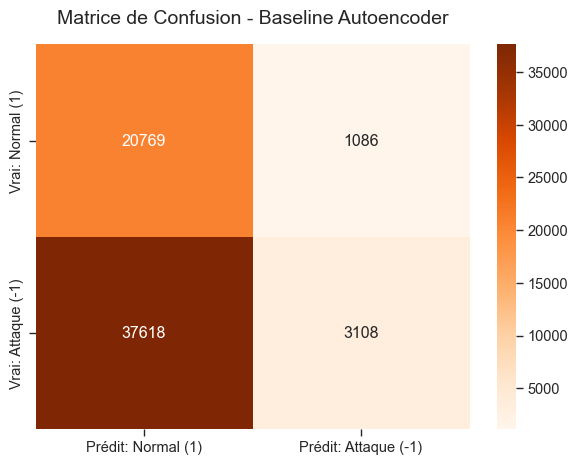

In [7]:
## 7. Modèle Baseline 2 : Autoencoder 

# Cellule 7 : Implémentation de l'Autoencoder (Tâche 2.2)
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("Début de la Tâche 2.2 : Construction de l'Autoencoder avec TensorFlow")

# 1. Conversion sécurisée en matrices Numpy 
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
input_dim = X_train_np.shape[1]

# 2. Architecture de l'Autoencoder
autoencoder = models.Sequential([
    # Encodeur 
    layers.InputLayer(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    
    # Décodeur
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mae')
print(autoencoder.summary())

# 3. Entraînement avec sécurité anti-surchauffe
print("\nEntraînement en cours ")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = autoencoder.fit(
    X_train_np, X_train_np,
    epochs=20,              # Limité à 20 cycles max
    batch_size=512,         
    validation_split=0.1,   # On garde 10% pour vérifier que le modèle ne surapprend pas
    callbacks=[early_stopping],
    verbose=1
)

# 4. Calcul de l'erreur de reconstruction
print("\nCalcul des erreurs mathématiques de reconstruction...")
# Prédiction sur le train set pour définir ce qui est "normal"
X_train_pred = autoencoder.predict(X_train_np)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train_np), axis=1)

# On fixe le seuil d'alerte : tout ce qui dépasse le 95ème percentile des erreurs normales est une attaque
threshold = np.percentile(train_mae_loss, 95)
print(f"-> Seuil de tolérance (Threshold) fixé à : {threshold:.4f}")

# Crash-Test sur les données inconnues (Attaques + Normal)
X_test_pred = autoencoder.predict(X_test_np)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test_np), axis=1)

# 5. Classification selon le seuil
# Convention : 1 = Normal (erreur sous le seuil), -1 = Attaque (erreur au-dessus du seuil)
y_pred_ae = np.where(test_mae_loss > threshold, -1, 1)

# 6. Extraction des Métriques Comparatives
print("\n--- RÉSULTATS DE L'AUTOENCODER ---")
f1_ae = f1_score(y_test_binary, y_pred_ae, pos_label=-1) 
acc_ae = accuracy_score(y_test_binary, y_pred_ae)

print(f"Exactitude Globale (Accuracy) : {acc_ae*100:.2f}%")
print(f"F1-Score (Détection d'anomalies) : {f1_ae:.4f}")

# 7. Matrice de confusion pour le rapport
cm_ae = confusion_matrix(y_test_binary, y_pred_ae, labels=[1, -1])
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prédit: Normal (1)', 'Prédit: Attaque (-1)'], 
            yticklabels=['Vrai: Normal (1)', 'Vrai: Attaque (-1)'])
plt.title("Matrice de Confusion - Baseline Autoencoder", fontsize=14, pad=15)
plt.show()

In [8]:
## 8. Exportation des modèles entraînés

# Cellule 8 : Sauvegarde des modèles entraînés (Checkpoint de fin de session)
import joblib
import os

print("Préparation de la sauvegarde des modèles.")

# 1. Création d'un dossier 'models' à la racine de ton projet
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

try:
    # 2. Sauvegarde de l'Isolation Forest avec joblib
    if_path = os.path.join(model_dir, 'isolation_forest_baseline.pkl')
    joblib.dump(iso_forest, if_path)
    print(f"Isolation Forest sauvegardée : {if_path}")

    # 3. Sauvegarde de l'Autoencoder (format natif Keras)
    ae_path = os.path.join(model_dir, 'autoencoder_baseline.keras')
    autoencoder.save(ae_path)
    print(f"Autoencoder sauvegardé : {ae_path}")
    
    print("\nSession terminée avec succès.")
except Exception as e:
    print(f"Erreur lors de la sauvegarde : {e}")

Préparation de la sauvegarde des modèles.
Isolation Forest sauvegardée : ../models\isolation_forest_baseline.pkl
Autoencoder sauvegardé : ../models\autoencoder_baseline.keras

Session terminée avec succès.
